In [5]:
import pandas as pd

df = pd.read_csv("titanic_sub.csv", index_col="PassengerId")

y = df["Survived"]
X = df.drop(columns="Survived")

X.head()

,Sex,Age,Pclass,Embarked
PassengerId,,,,
1,male,22.0,3,S
2,female,38.0,1,C
3,female,26.0,3,S
4,female,35.0,1,S
5,male,35.0,3,S


In [6]:
X.isna().sum()

Sex           0
Age         177
Pclass        0
Embarked      2
dtype: int64

In [7]:
X["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [8]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [9]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

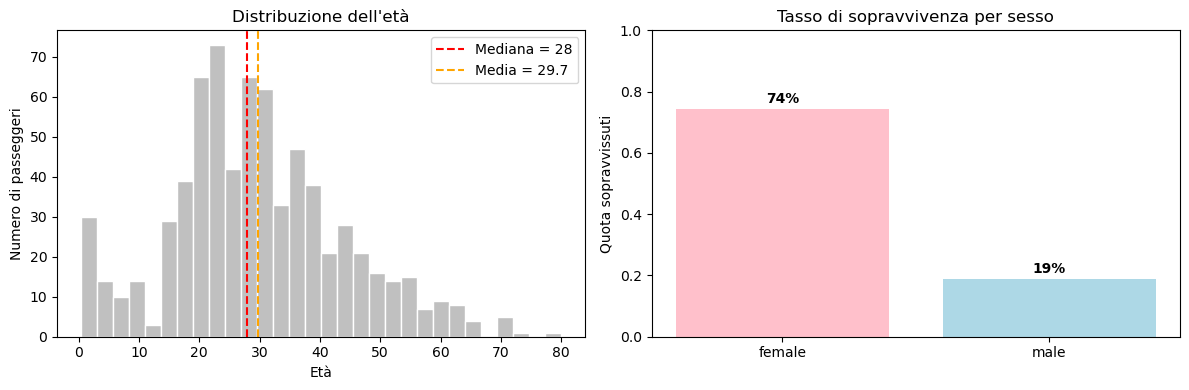

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X["Age"].dropna(), bins=30, color="silver", edgecolor="white")
axes[0].axvline(X["Age"].median(), color="red", linestyle="--", label=f"Mediana = {X['Age'].median():.0f}")
axes[0].axvline(X["Age"].mean(), color="orange", linestyle="--", label=f"Media = {X['Age'].mean():.1f}")
axes[0].set_title("Distribuzione dell'età")
axes[0].set_xlabel("Età")
axes[0].set_ylabel("Numero di passeggeri")
axes[0].legend()

# Grafico 2: sopravvivenza per sesso
tassi = df.groupby("Sex")["Survived"].mean()
axes[1].bar(tassi.index, tassi.values, color=["pink", "lightblue"])
axes[1].set_title("Tasso di sopravvivenza per sesso")
axes[1].set_ylabel("Quota sopravvissuti")
axes[1].set_ylim(0, 1)
for i, v in enumerate(tassi.values):
    axes[1].text(i, v + 0.02, f"{v:.0%}", ha="center")

plt.tight_layout()
plt.show()

## Analisi esplorativa

**Valori mancanti:** `Age` ne ha 177, `Embarked` 2. Vanno imputati.

**Scelta dell'imputazione per `Age`:** media 29,7 contro mediana 28,0, con massimo a 80 anni. La media è spinta verso l'alto dai pochi passeggeri anziani: la **mediana** è più robusta agli outlier ed è la scelta adottata. Per `Embarked`, categorica, uso il **valore più frequente**.

**Le feature sono predittive:**
- **Sesso**, sopravvivenza femmine 74%, maschi 19%.
- **Classe**, prima 63%, seconda 47%, terza 24%.

I divari netti confermano che i dati hanno struttura reale.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(668, 4) (223, 4)
0.38323353293413176 0.38565022421524664


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

num = ["Age"]
cat = ["Sex", "Embarked"]

trasf_num = SimpleImputer(strategy="median")

trasf_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessore = ColumnTransformer([
    ("num", trasf_num, num),
    ("cat", trasf_cat, cat),
], remainder="passthrough") 

pipe = Pipeline([
    ("prep", preprocessore),
    ("albero", DecisionTreeClassifier(random_state=0)),
])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('albero', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [13]:
from sklearn.model_selection import GridSearchCV

griglia = {"albero__max_depth": [2, 5, 10, 25, None]}

gs = GridSearchCV(
    pipe,
    griglia,
    cv=5,
    scoring="accuracy",
)
gs.fit(X_train, y_train)

print("Migliore profondità:", gs.best_params_)
print("Accuratezza media in CV:", round(gs.best_score_, 4))

Migliore profondità: {'albero__max_depth': 5}
Accuratezza media in CV: 0.8158


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipe_baseline = Pipeline([
    ("prep", preprocessore),
    ("logreg", LogisticRegression(max_iter=1000, random_state=0)),
])

score_baseline = cross_val_score(pipe_baseline, X_train, y_train, cv=5, scoring="accuracy")
print("Baseline (LogReg) — accuratezza media CV:", round(score_baseline.mean(), 4))

Baseline (LogReg) — accuratezza media CV: 0.7963


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pred_test = gs.predict(X_test)

print("Accuratezza sul test:", round(accuracy_score(y_test, pred_test), 4))
print()
print(classification_report(y_test, pred_test, target_names=["Non sopravvissuto", "Sopravvissuto"]))
print("Matrice di confusione:")
print(confusion_matrix(y_test, pred_test))

Accuratezza sul test: 0.7713

                   precision    recall  f1-score   support

Non sopravvissuto       0.75      0.93      0.83       137
    Sopravvissuto       0.83      0.51      0.63        86

         accuracy                           0.77       223
        macro avg       0.79      0.72      0.73       223
     weighted avg       0.78      0.77      0.76       223

Matrice di confusione:
[[128   9]
 [ 42  44]]


## Risultati

Il modello finale è un **albero di decisione (profondità 5)**, scelta via cross-validation a 5 fold dentro una pipeline che imputa e codifica **solo sul training**, senza data leakage.

**Performance sul test set:** accuratezza **77,1%**, contro una baseline di regressione logistica al **79,6% in CV**, l'albero (81,6% in cross-validation) aggiunge un margine reale ma contenuto: il problema è affrontabile anche con un modello lineare.

**Il limite del modello** emerge solo guardando oltre l'accuratezza:

| Classe | Recall |
|---|---|
| Non sopravvissuto | 0,93 |
| Sopravvissuto | 0,51 |

Il modello riconosce quasi tutti i non-sopravvissuti ma ne manca circa la metà tra i sopravvissuti (42 falsi negativi su 86). È **sbilanciato verso la classe maggioritaria**: la sola accuratezza lo avrebbe nascosto, la matrice di confusione lo rivela.

**Nota metodologica:** una prima versione del progetto raggiungeva l'80,3% sul test, ma quel valore era inficiato da data leakage: mediana, moda e codifiche venivano calcolate sull'intero dataset prima dello split. Corretto il metodo con una pipeline, il risultato reale è più basso (77,1%) e affidabile.